# **About the notebook, data and story:** 

This notebook contains the **Shutdown Tracker Optimization Project (STOP)** dataset from  **Access Now**, an NGO that records internet shutdowns across the globe, to evaluate the country with the highest frequency of shutdowns **(India)** between 2016 - 2025 and the areas in the country where they are the most concentrated. In addition to the data from Access Now, this notebook also contains data from the **World Bank** documenting yearly growth in internet users in India from 2015 - 2025.  

**Key Questions:**

1) #### **WHERE**
- Which country has the most frequent shutdowns of those included in the STOP dataset to date? - **India**
  
- How many internet shutdowns has the country (India) with the most frequent shutdowns had between 2016 - 2025? - **India - estimated 900+ shutdowns**

- How many days has India undergone internet shutdowns in total / what's the average shutdown length? - **Total estimated days = 8,804 & Avg days = just under 10**  

2) #### **WHY & WHO & WHAT:**
- What are the most frequent "actual causes" behind internet shutdowns in India (have they been for exams, because of conflict, etc.)? - **conflict & protests nearly tie for "actual causes" across the country, not for specific areas where the shutdowns are concentrated**

- What are the main reasons/"actual causes" for shutdowns in the 3 areas in India with the most frequent shutdowns? - **J&K:** Political Instability, other & protests ; **Manipur:** Communal violence, protests, political instability ; **Rajasthan:** Communal violence, protests, exam cheating. 

- What is primary "government justification" behind the shutdowns in these 3 areas? - **J&K:** National Security/Counter-Terrorism; **Manipur:** Fake News/ Hate Speech/ Incendiary Content/ Promoting Violence; **Rajasthan:** Public Safety/ Quell Unrest/ Restore Public Order.
  
- Who initiated the internet shutdowns? (was it government authorities, militant groups, law enforcement, etc.?) - **Ordered primarily by: state gov followed by local gov**

  
- Who was impacted by these shutdowns/how did they impact communities in these regions? Which shutdowns have been the most significant? **answered with articles/outside research**

- **J&K:** The 2019 - 2021 shutdown after being stripped of its special status was one of the longest shutdowns ever recorded in a democracy. The region is also undergoing a communications blockage - 14 messaging apps were banned starting in 2023. 

-**Manipur** The state had only 1 - 2 shutdowns a year, if any, until 2023 when they had an estimated 47 shutdowns. These shutdowns coincided with escalating ethnic tensions between the Meitei and Kuki communities, which are still ongoing. 

- **Rajasthan** This state is known for its shutdowns during exams, and its longest shutdown (based on Access Now data) was caused by a protest and lasted 14 days. 

4) #### **TIME:**
- When were India's internet shutdowns, what year(s)? Where were the biggest spikes in shutdowns between 2016 - 2025? 
  
- What was the **type** of shutdown that occured the most in top 3 areas that have most shutdowns?

- Which were the longest shutdowns/how long did they last?

5) #### **Cross Ref with outside reports & World Bank internet user data**

- Used news reports from various sources/organizations to provide additional context to the reason why shutdowns are so frequent in these three regions/the most prominent aspects of the shutdowns and used world bank data to compare internet user percentages from the time Digital India was implemented. 


## **Step 1:** Import the Access Now Excel Sheet as a CSV to explore the data and find its info, column/row names, variables to work with, etc.

In [1]:
import pandas as pd 

df = pd.read_csv('STOP_Data 2016-2025.csv') 
#Reminder: sheet_name=None means I wanna read every sheet in the excel file .

In [2]:
len(df) #shows number of OG rows -> 2102

#checked this number in Access Now report and this number is accurate. 

2102

In [3]:
df

,start_date_type,start_date,country,geo_scope,area_name,shutdown_type,affected_network,shutdown_extent,ordered_by,decision_maker,...,violence,hr_abuse_reported,users_targeted,users_target_detail,users_notified,econ_impact,event,an_link,region,count_year
0,NaN,1/1/2009,Pakistan,"It only affected one city, county, or village","Wana, South Waziristan",Shutdown,Mobile,Full network,Local government,NaN,...,NaN,NaN,NaN,NaN,NaN,52437355 / year,NaN,NaN,APAC,2016
1,Estimated,5/24/2009,Iran (Islamic Republic of),"It affected locations in more than one state, ...",Nationwide,Shutdown,"Broadband, Mobile",Service-based,Executive government,NaN,...,No,No,NaN,NaN,No,NaN,Facebook and Twitter were banned formally in I...,NaN,MENA,2016
2,Actual,9/11/2013,Turkey,"It affected locations in more than one state, ...",Nationwide,Shutdown,"Broadband, Mobile",Service-based,Executive government,Turkey's Directorate of Telecommunication foll...,...,No,No,LGBTQ groups,NaN,No,NaN,Grindr has been blocked in Turkey since Sep. 1...,NaN,MENA,2016
3,NaN,1/26/2016,India,It affected more than one city in the same sta...,Kashmir,Shutdown,"Broadband, Mobile",Full network,Local government,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Republic Day,NaN,APAC,2016
4,NaN,2/16/2016,Morocco,"It affected locations in more than one state, ...",nationwide,Shutdown,"Broadband, Mobile",Service-based,Executive government,NaN,...,NaN,NaN,NaN,NaN,NaN,"$1,760,747",NaN,https://www.accessnow.org/etisalat-shuts-off-s...,MENA,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2097,Actual,12/24/2025,Myanmar,"It only affected one city, county, or village","Thanlyin township, Yangon Region",Shutdown,Mobile,Full network,Military,Military junta,...,No,No,NaN,NaN,No,NaN,Internet service and phone lines were cut off ...,NaN,APAC,2025
2098,Actual,12/26/2025,India,"It only affected one city, county, or village","Chomu town, Jaipur District, Rajasthan",Shutdown,Unknown,Full network,Local government,Divisional Commissioner Poonam,...,Yes,Unknown,NaN,NaN,No,NaN,Internet services were suspended in Chomu town...,NaN,APAC,2025
2099,Actual,12/27/2025,Myanmar,"It affected locations in more than one state, ...",Cities and townships across Myanmar,Shutdown,Mobile,Full network,Military,Military junta,...,Unknown,Unknown,NaN,NaN,No,NaN,An increase in internet service and phone line...,NaN,APAC,2025
2100,Actual,12/27/2025,India,"It only affected one city, county, or village","Chomu town, Jaipur District, Rajasthan",Shutdown,Unknown,Full network,Local government,Divisional Commissioner Poonam,...,Unknown,Unknown,NaN,NaN,No,NaN,"In an extension of a previous order, internet ...",NaN,APAC,2025


In [4]:
print(df.keys()) 

#helped find combined rows I want to use for 2016-2025 that I used above.

Index(['start_date_type', 'start_date', 'country', 'geo_scope', 'area_name',
       'shutdown_type', 'affected_network', 'shutdown_extent', 'ordered_by',
       'decision_maker', 'actual_cause', 'actual_cause_details', 'info_source',
       'info_source_link', 'shutdown_status', 'end_date', 'duration',
       'gov_justification', 'gov_just_details', 'gov_ack', 'legal_just',
       'legal_method', 'gov_ack_source', 'gov_ack_quote', 'facebook_affected',
       'twitter_affected', 'whatsapp_affected', 'instagram_affected',
       'telegram_affected', 'other_affected', 'sms_affected',
       'phonecall_affected', 'telcos_involved', 'telco_ack',
       'telco_ack_source', 'telco_ack_quote', 'election', 'violence',
       'hr_abuse_reported', 'users_targeted', 'users_target_detail',
       'users_notified', 'econ_impact', 'event', 'an_link', 'region',
       'count_year'],
      dtype='str')


In [5]:
df.shape 

#shows number of columns (47) & rows (2102)

(2102, 47)

In [6]:
df.head() #^^^shows categories/rows

,start_date_type,start_date,country,geo_scope,area_name,shutdown_type,affected_network,shutdown_extent,ordered_by,decision_maker,...,violence,hr_abuse_reported,users_targeted,users_target_detail,users_notified,econ_impact,event,an_link,region,count_year
0,NaN,1/1/2009,Pakistan,"It only affected one city, county, or village","Wana, South Waziristan",Shutdown,Mobile,Full network,Local government,NaN,...,NaN,NaN,NaN,NaN,NaN,52437355 / year,NaN,NaN,APAC,2016
1,Estimated,5/24/2009,Iran (Islamic Republic of),"It affected locations in more than one state, ...",Nationwide,Shutdown,"Broadband, Mobile",Service-based,Executive government,NaN,...,No,No,NaN,NaN,No,NaN,Facebook and Twitter were banned formally in I...,NaN,MENA,2016
2,Actual,9/11/2013,Turkey,"It affected locations in more than one state, ...",Nationwide,Shutdown,"Broadband, Mobile",Service-based,Executive government,Turkey's Directorate of Telecommunication foll...,...,No,No,LGBTQ groups,NaN,No,NaN,Grindr has been blocked in Turkey since Sep. 1...,NaN,MENA,2016
3,NaN,1/26/2016,India,It affected more than one city in the same sta...,Kashmir,Shutdown,"Broadband, Mobile",Full network,Local government,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Republic Day,NaN,APAC,2016
4,NaN,2/16/2016,Morocco,"It affected locations in more than one state, ...",nationwide,Shutdown,"Broadband, Mobile",Service-based,Executive government,NaN,...,NaN,NaN,NaN,NaN,NaN,"$1,760,747",NaN,https://www.accessnow.org/etisalat-shuts-off-s...,MENA,2016


In [7]:
df.info() #names of columns, null values, types (like str, int, float), etc.

<class 'pandas.DataFrame'>
RangeIndex: 2102 entries, 0 to 2101
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   start_date_type       1511 non-null   str  
 1   start_date            2102 non-null   str  
 2   country               2102 non-null   str  
 3   geo_scope             2096 non-null   str  
 4   area_name             2071 non-null   str  
 5   shutdown_type         2102 non-null   str  
 6   affected_network      2102 non-null   str  
 7   shutdown_extent       2102 non-null   str  
 8   ordered_by            2098 non-null   str  
 9   decision_maker        1208 non-null   str  
 10  actual_cause          2102 non-null   str  
 11  actual_cause_details  1229 non-null   str  
 12  info_source           2095 non-null   str  
 13  info_source_link      2074 non-null   str  
 14  shutdown_status       1667 non-null   str  
 15  end_date              1389 non-null   str  
 16  duration         

## **Step 2:** Find the country with the highest number of internet shutdowns / highest frequency of shutdowns (it's India).

In [8]:
frequency = df['country'].value_counts()

#OG code to find top 5 countries with most shutdowns since 2016.

#records number of recorded shutdown events per country in top 5 -> countries with most
#frequent shutdowns 

#India has the most frequent shutdowns (907) but Iran (look below) has highest number of days 
#in which its country has experienced internet shutdowns.

In [9]:
df_frequency = frequency.reset_index()

In [10]:
df_frequency.head(5)

,country,count
0,India,920
1,Myanmar,244
2,Pakistan,101
3,Iran (Islamic Republic of),99
4,Ukraine,49


#### **TA comments from July 17 (Fri) on above code on how to find the country with the highest number of internet shutdowns since 2016**

**My original code:** df['country'].value_counts().head(5)

- The above code gave me India, Myanmar, Pakistan, Iran and Ukraine as countries with most internet shutdowns. This code, if found to accurately depict accounts of the shutdowns, shows that India significantly exceeds the other top 5 countries, surpassing Myanmar by 693 shutdowns (if true, notable shutdown is 6/29/2020 shutdown of tiktok over conflict with China).

##### **Issue Explained:**
  
- When showing the TA's they said there could be a chance that just counting the number of times the country names appear may be not accurately indicate the country with the most shutdowns since the rows list the shutdown events, but the events are not equal in size **(nationwide vs several cities / 1 day vs 1 week).** They said I may need to "standardize it" because **one country could have one big shutdown nationwide and others could have multiple targeted shutdowns** rather than nationwide ones potentially skewing data. The TA's also said something about initially starting with days spent under shutdown and then making a shape file **(follow up on this idea)** but that the **country's name** appearing may also accurately indicate **most shutdowns.**

- **How I understand it:** A country could experience 5 localized shutdowns that last one day while another country could have a 4 day long shutdown nationwide, but the localized shutdowns would be placed above the latter because **value_counts() may just highlight number of events, not one long disruption over several days, in turn counting a shutdown over several days as just one event.**
  
- TA's said looping the **end_date and start_date makes every row a duration, putting them in the same unit before comparing for highest number, and that summing durations per country shows total days a country experienced internet shutdowns over the years.**

##### **New Potential Issue:**

- While all countries are listed with estimated and actual start dates for shutdowns, not all of them recorded by Access Now have ended, and the org has listed some as ongoing or with unknown status, which may impact accuracy of the dates idea.

##### **TA Code Ideas:**
- TA's said looping the **end_date and start_date makes every row a duration, putting them in the same unit before comparing for highest number of shutdowns, and that summing durations per country shows total days a country experienced internet shutdowns over the years.**

**1.** Do a **For Loop** to distinguish between shutdowns to determine the **number of days per year** that some country had a shutdown in effect. 

**2.** For every row (in For Loop) make it go through the **start date** and the **end date** to **calculate difference** for each row in order to find the country with highest number of shutdowns by then **summing it for every country** to see which had the **highest number of days.** 

**TA Jul 19 explanation for above:**

- confirmed For Loop idea for start_date & end_date is the way to go and said to use "current date function" for **ongoing internet shutdowns** and make note that **as of this day X country has X number of internet shutdowns.**

- for the **"unknown" end dates**, said I can just mark it as **1 day** and add note/annotation that there were unknown periods of duration and can assume it just lasts 1 day. 

In [11]:
df.columns #review names again - checked duration and many are missing in sheets

Index(['start_date_type', 'start_date', 'country', 'geo_scope', 'area_name',
       'shutdown_type', 'affected_network', 'shutdown_extent', 'ordered_by',
       'decision_maker', 'actual_cause', 'actual_cause_details', 'info_source',
       'info_source_link', 'shutdown_status', 'end_date', 'duration',
       'gov_justification', 'gov_just_details', 'gov_ack', 'legal_just',
       'legal_method', 'gov_ack_source', 'gov_ack_quote', 'facebook_affected',
       'twitter_affected', 'whatsapp_affected', 'instagram_affected',
       'telegram_affected', 'other_affected', 'sms_affected',
       'phonecall_affected', 'telcos_involved', 'telco_ack',
       'telco_ack_source', 'telco_ack_quote', 'election', 'violence',
       'hr_abuse_reported', 'users_targeted', 'users_target_detail',
       'users_notified', 'econ_impact', 'event', 'an_link', 'region',
       'count_year'],
      dtype='str')

## **Step 3:** We have the frequency showing India with the highest number of shutdowns but now want to see how many days the country has undergone shutdowns and the average length of internet shutdowns there. Also want to compare to other countries, such as Iran, which has the longest shutdowns but has a lower frequency. For this did some calculations with the start_date and end_date columns to sum them and get the average number of days for shutdowns in India and other countries in the CSV.

In [12]:
# df['start_date'] = df['start_date'].str.replace(r'[a-zA-Z]', '', regex=True)

#there was text in the date column for one of the countries in the dataset so had to remove
#it with regex. It was in the end_date column, so had to comment out the start_date. 
df['end_date'] = df['end_date'].str.replace(r'[a-zA-Z]', '', regex=True)                                               

In [13]:
#make date columns real dates 

# google said either pd.Timestamp.today() or pd.to_datetime('today') work.

df["start_date"] = pd.to_datetime(df["start_date"], format ='mixed')
df["end_date"] = pd.to_datetime(df["end_date"], format ='mixed')

In [14]:
df.dtypes

start_date_type                    str
start_date              datetime64[us]
country                            str
geo_scope                          str
area_name                          str
shutdown_type                      str
affected_network                   str
shutdown_extent                    str
ordered_by                         str
decision_maker                     str
actual_cause                       str
actual_cause_details               str
info_source                        str
info_source_link                   str
shutdown_status                    str
end_date                datetime64[us]
duration                           str
gov_justification                  str
gov_just_details                   str
gov_ack                            str
legal_just                         str
legal_method                       str
gov_ack_source                     str
gov_ack_quote                      str
facebook_affected                  str
twitter_affected         

In [15]:
#variable for today's date 

today = pd.Timestamp.today()

In [16]:
df = df.reset_index(drop=True) 
#had error in for loop b/c rows were out of order so fixed them before running again.

In [17]:
#make empty dictionary for countries that'll hold total shutdown days per country

country_days = {}

In [18]:
for row in range(len(df)): #could also have used .iterrows():

    start = df["start_date"][row]
    end = df["end_date"][row]
    country = df["country"][row]

    # If shutdown is still ongoing, use today's date:
    if df["shutdown_status"][row] == "Ongoing":
        end = today #today as in Sunday - July 19, 2026

    # If end date is missing, count it as 1 day:
    elif pd.isna(end): #isna means that the value is null
        end = start 

    # Calculate number of days:
    days = (end - start).days + 1 
    #this line applies to both if and elif above. It makes it so that unknown end dates are only counted as 1 day
    #it also makes sure it counts the total number of days as whole even if only a day and a half.


    # Add days to that country's total:
    if country in country_days:
        country_days[country] = country_days[country] + days 
    else:
        country_days[country] = days

In [19]:
country_days

{'Pakistan': 49044,
 'Iran (Islamic Republic of)': 131554,
 'Turkey': 54405,
 'India': 21875,
 'Morocco': 2,
 'Uganda': 10143,
 'Saudi Arabia': 31132,
 'North Korea': 2,
 'Chad': 3621,
 'Brazil': 53,
 'Viet Nam': 104,
 'Iraq': 4131,
 'Ethiopia': 18292,
 'Syrian Arab Republic': 361,
 'Algeria': 58,
 'Bahrain': 3692,
 'Zimbabwe': 12,
 'Libya': 19,
 'Bangladesh': 2939,
 'Mali': 2247,
 'Gabon': 41,
 'Uzbekistan': 299,
 'Indonesia': 39122,
 'Egypt': 8,
 'Montenegro': 1,
 'United Arab Emirates': 35630,
 'Gambia': 3,
 'Congo (Democratic Republic of the)': 428,
 'Philippines': 4,
 'Cameroon': 291,
 'Belarus': 126,
 'Ukraine': 30993,
 'China': 21639,
 'Togo': 168,
 'Equatorial Guinea': 1499,
 'Somaliland': 3,
 'Yemen': 9732,
 'South Korea': 4,
 'Sri Lanka': 28,
 'Kazakhstan': 3089,
 'Sierra Leone': 4,
 'Russian Federation': 25281,
 "Côte d'Ivoire": 21,
 'Nicaragua': 2,
 'Nigeria': 9844,
 'Sudan': 886,
 'Jordan': 18559,
 'Venezuela (Bolivarian Republic of)': 1490,
 'Tajikistan': 301,
 'Benin': 5

In [20]:
country_days = pd.DataFrame(country_days, index=[0])

In [21]:
country2 = country_days.transpose() #helps us find days of shutdown countries have experienced

In [22]:
country2.columns = ["Total Shutdown Days"]
country2 #we find that Iran has experienced the most days of shutdowns (diff from frequency)

,Total Shutdown Days
Pakistan,49044
Iran (Islamic Republic of),131554
Turkey,54405
India,21875
Morocco,2
...,...
Lithuania,448
Cambodia,2
Panama,18
Angola,1


In [23]:
country3 = country2.reset_index()

In [24]:
country3

,index,Total Shutdown Days
0,Pakistan,49044
1,Iran (Islamic Republic of),131554
2,Turkey,54405
3,India,21875
4,Morocco,2
...,...,...
95,Lithuania,448
96,Cambodia,2
97,Panama,18
98,Angola,1


In [25]:
len(country3) #check to ensure it matches number of countries found in OG DF (100)

100

In [26]:
df['country'].value_counts().head(5) #check top 5 countries for frequency of shutdowns

country
India                         920
Myanmar                       244
Pakistan                      101
Iran (Islamic Republic of)     99
Ukraine                        49
Name: count, dtype: int64

#### **Below is code from when I had a top5_df for top 5 countries with highest frequency of internet shutdown instances/most internet shutdowns from 2016 - 2025. replaced earlier with freuency df.**

In [27]:
#country_days = pd.Series(country_days).sort_values(ascending=False)
#country_days.head(5)

#result isnt number of days for shutdowns -> it just separates shutdowns to where let's say
#there were 10 shutdowns in India one day and it was listed as 1 shutdown now it shows as 10 diff 
#shutdowns. 

In [28]:
#top5_countries = country_days.head(5) 

#need to get top 5 in a DF to make a chart in datawrapper showing how much India exceeds others

In [29]:
#top5_df = top5_countries.reset_index()

In [30]:
#top5_df

In [31]:
#rename the column names so it will have country and then total shutdown days so easier to read
#top5_df.columns = ["country", "Total Shutdown Days"] 

In [32]:
#top5_df
#ran again to see if the column names changed 

In [33]:
merged = pd.merge(country3, df_frequency, left_on='index', right_on='country', how='inner')

#this code merges dataframes so i have country, the total shutdown days they've experienced,
#the count of shutdowns (aka frequency/how many times), and average for how long they last

In [34]:
merged = merged.drop(columns=["country"])

In [35]:
merged['average_length'] = merged ['Total Shutdown Days']/merged['count']

In [36]:
merged

,index,Total Shutdown Days,count,average_length
0,Pakistan,49044,101,485.584158
1,Iran (Islamic Republic of),131554,99,1328.828283
2,Turkey,54405,27,2015.000000
3,India,21875,920,23.777174
4,Morocco,2,2,1.000000
...,...,...,...,...
95,Lithuania,448,1,448.000000
96,Cambodia,2,2,1.000000
97,Panama,18,2,9.000000
98,Angola,1,1,1.000000


In [37]:
merged = merged.sort_values('Total Shutdown Days', ascending=False)
merged

#just puts the merged DF in order 

,index,Total Shutdown Days,count,average_length
1,Iran (Islamic Republic of),131554,99,1328.828283
55,Myanmar,55039,244,225.569672
2,Turkey,54405,27,2015.000000
0,Pakistan,49044,101,485.584158
22,Indonesia,39122,17,2301.294118
...,...,...,...,...
84,Israel,1,1,1.000000
77,Tunisia,1,1,1.000000
72,Zambia,1,1,1.000000
24,Montenegro,1,1,1.000000


In [38]:
len(merged)

100

### **Analysis 1 (Step 2 & 3):** 
India has had the highest number of internet shutdown events (over 900) in the Access Now STOP dataset. Although it has the most frequent shutdowns, they are not nearly as long as some in other countries in terms of consecutive days. Iran takes first place for the number of days internet shutdowns have been put in place. From the above data analysis/code, we know that India's shutdowns are the most frequent, but shorter. 

## **Step 4:** Find what the actual cause(s) behind the shutdowns in India as a whole are (not specific areas yet) that have occurred the most in the past decade (have they been for exams, because of conflict, etc.) and who initiated and executed these shutdowns, and what were the government justifications?

In [39]:
#look at: 'ordered_by','decision_maker', 'actual_cause', 'actual_cause_details'
#actual cause details are mostly empty, so wouldn't help much for analysis. 

india = df[df["country"] == "India"]

#### **Finding the actual cause of internet shutdowns in India**

In [40]:
#find main reasons shutdowns occurred

india["actual_cause"].value_counts()

#make into a DF so easier to read 

actualCause_df = india["actual_cause"].value_counts().head(15).reset_index()
actualCause_df

#Protests and Poltical Instability are nearly tied for the top "actual cause" of internet shutdowns.

,actual_cause,count
0,Political instability,216
1,Protests,212
2,Communal violence,177
3,Other,111
4,Conflict,53
5,Unknown,52
6,Religious holiday/anniversary,30
7,Information control,27
8,Exam cheating,21
9,Elections,18


In [41]:
#checking to ensure it adds up to 907 which is number of shutdowns in India recorded in CSV
india['actual_cause'].value_counts()

#(212+211+176+111+52+48+30+25+21+18+3) = 907

actual_cause
Political instability             216
Protests                          212
Communal violence                 177
Other                             111
Conflict                           53
Unknown                            52
Religious holiday/anniversary      30
Information control                27
Exam cheating                      21
Elections                          18
Visits by government officials      3
Name: count, dtype: int64

#### **Finding the most frequent gov justification for internet shutdowns in India**

In [42]:
#find main gov justifications for shutdowns that occurred

india["gov_justification"] = india["gov_justification"].str.strip()
india["gov_justification"] = india["gov_justification"].replace('School Exams', 'School exams')

india["gov_justification"].value_counts()

#make into a DF so easier to read 

gov_justification_all_India_df = india["gov_justification"].value_counts().head(25).reset_index()
gov_justification_all_India_df

,gov_justification,count
0,Fake news/ Hate speech/ Incendiary content/ Pr...,283
1,Public safety/ Quell unrest/ Restore public order,225
2,National security/ Counter-terrorism,153
3,Precautionary measure,100
4,Unknown,80
5,Other,53
6,School exams,20


#### **Finding who ordered internet shutdowns in India the most**

In [43]:
#find who ordered the shutdowns most

india["ordered_by"].value_counts()

#make into DF so easier to read 

orderedBy_df = india["ordered_by"].value_counts().head(10).reset_index()
orderedBy_df

#State government has ordered the most shutdowns, greatly exceeding local government in 2nd place.

,ordered_by,count
0,State government,512
1,Local government,276
2,Unknown,64
3,Law enforcement,43
4,Executive government,24
5,Non-government,1


#### **Finding the decision makers that appear most for the internet shutdowns in India**

In [44]:
#find who made the decision for shutdowns most

india["decision_maker"].value_counts()

decision_maker
Government of Jammu & Kashmir, Home Department            105
Inspector General of Police, Kashmir zone                  76
Government of Jammu and Kashmir, Home Department           72
Government of Manipur, Home Department                     69
State government                                           43
                                                         ... 
Superintendent of Police, North Tripura, Dharmanagar        1
Superintendent of Police, Vikarabad, K. Narayana Reddy      1
Deputy Commissioner Poonamdeep Kaur                         1
Bhadrak Superintendent of Police (SP) Manoj Rout            1
District Magistrate of Dhalai, Vivek HB                     1
Name: count, Length: 110, dtype: int64

In [45]:
#notice that gov of "jammu and kashmir ..." are the same, one just uses "and" while the other uses
# &. So below code is to combine the two for analysis given they're the same entity but counted as 
#2 different things.

india["decision_maker"] = india["decision_maker"].replace(
    "Government of Jammu and Kashmir, Home Department",
    "Government of Jammu & Kashmir, Home Department"
)

In [46]:
india["decision_maker"].value_counts().head(20)

india['decision_maker'] = india['decision_maker'].str.replace('Jammu and Kashmir', 'Jammu & Kashmir')
india['decision_maker'].value_counts().head(10)

#put above info into a DF below so easier to read 


decision_df = india["decision_maker"].value_counts().head(20).reset_index()
decision_df

#The Government of Jammu & Kashmir, Home Department was the biggest decision maker , followed by 
#Inspector General of Police, Kashmir zone. Government of Manipur, Home Department, comes in 3rd.

#Manipur and Kashmir are on opposite sides of India, with Kashmir & Jammu bordering Pakistan, 
#Afghanistan, Tajikistan, and China and Manipur on the opposite side near the border of Myanmar.

,decision_maker,count
0,"Government of Jammu & Kashmir, Home Department",177
1,"Inspector General of Police, Kashmir zone",76
2,"Government of Manipur, Home Department",69
3,State government,43
4,"Government of Haryana, Department of Home Affairs",30
5,"Government of Bihar, Home Department",19
6,Jammu & Kashmir State Government,15
7,"Government of Odisha, Home Department",14
8,"Government of West Bengal, Home & Hill Affairs...",13
9,"Inspector General of the Kashmir Police, later...",10


### **Analysis 2:**

**Actual_cause all India:** 
Protests                          212,
Political instability             211,
Communal violence                 176,
Other                             111.

Protests and political instability nearly tied for the top cause for internet shutdowns in India. Communal violence was not far behind, appearing 176 times.

**Ordered_by all India:** India's internet shutdowns between 2016 - 2025 have most often been ordered by state government (507), followed by local government (275). Law enforcement and executive government and non-government do not come close to state and local government when it comes to shutdown authorization, nor does "other." Also 507 + 275 = 782 of 907 ordered at state/local level is (86%) of shutdowns.

**Decision_maker all India:** The decision maker that appears the most in Access Now's dataset is the Government of Jammu & Kashmir, Home Department **(175)**, followed by the Inspector General of Police, Kashmir zone **(75)**, and the Government of Manipur, Home Department **(68)**. These are all regional authorities. If combining regional authorities for Jammu & Kashmir real number would be **250**. The decision maker appearing within J&K the most often makes sense given the number of shutdowns there, and just further specifies who chose to ordered the shutdowns.

**Interesting to note all India:** Something interesting to note is that Manipur and Kashmir are on opposite sides of India, with **Kashmir & Jammu bordering Pakistan and China and nearly bordering Afghanistan and Tajikistan** and **Manipur on the opposite side near the border of Myanmar (which has second most frequent shutdowns**. Both are near very politically contentious countries and are politically contentious themselves. 



## **Step 5:** Find where the shutdowns in India have occured the most/where shutdowns are most concentrated in India. (J&K, Rajasthan and Manipur)

Need to connect this info to above as we know the entities that have ordered them are primarily state-level authorities. Zoom in more to better understand the areas the shudowns have occurred the most and to find those who are impacted most by internet shutdowns.

### Finding the area/state names where shutdowns have occurred throughout India.

In [47]:
india["area_name"].value_counts().head(20)
#shows every individual area name in the data and how many shutdown events happened there

#put above info into a DF below so easier to read 


indiaArea_df = india["area_name"].value_counts().reset_index()
indiaArea_df

#we can see that Manipur comes up often along with districts in Jammu and Kashmir. 
#look at code two cells below to see how all districts in Jammu and Kashmir were put together to find 
#number of shutdowns in the region by combining districts in the region together. 
#To be safe also did this for Manipur since it ranked first for now. 

,area_name,count
0,Manipur,48
1,"Srinagar, Jammu & Kashmir",23
2,"Shopian, Jammu and Kashmir",19
3,"Srinagar, Kulgam, Pulwama, Anantnag, Jammu and...",18
4,"Pulwama, Jammu and Kashmir",15
...,...,...
536,"Bhiwani District, Haryana",1
537,"Leh District, Ladakh",1
538,"Hathwa sub-division, Gopalganj District, Bihar",1
539,"Baksa District, Assam",1


#### **Finding the number of internet shutdowns per top 3 regions that have had the most**

In [48]:
#took the names of the 28 states of india and filetered them to see number for each. knew J&K had diff variation,
#and made several variations for it here but cannot use these to add up since they overlap so fixes in cell below.


states = [
    "Andhra Pradesh", "Arunachal Pradesh", "Assam", "Bihar",
    "Chhattisgarh", "Goa", "Gujarat", "Haryana",
    "Himachal Pradesh", "Jharkhand", "Karnataka", "Kerala",
    "Madhya Pradesh", "Maharashtra", "Manipur", "Meghalaya",
    "Mizoram", "Nagaland", "Odisha", "Punjab",
    "Rajasthan", "Sikkim", "Tamil Nadu", "Telangana",
    "Tripura", "Uttar Pradesh", "Uttarakhand", "West Bengal",
    "Jammu & Kashmir", "Jammu and Kashmir", "Jammu", "Kashmir"
]

for state in states:
    count = india['area_name'].str.contains(state, case=False, na=False).sum()
    print(state, count)

Andhra Pradesh 2
Arunachal Pradesh 8
Assam 11
Bihar 32
Chhattisgarh 1
Goa 0
Gujarat 3
Haryana 45
Himachal Pradesh 0
Jharkhand 8
Karnataka 1
Kerala 0
Madhya Pradesh 8
Maharashtra 19
Manipur 75
Meghalaya 6
Mizoram 0
Nagaland 4
Odisha 21
Punjab 18
Rajasthan 77
Sikkim 0
Tamil Nadu 0
Telangana 4
Tripura 8
Uttar Pradesh 29
Uttarakhand 2
West Bengal 31
Jammu & Kashmir 142
Jammu and Kashmir 287
Jammu 435
Kashmir 465


In [49]:
#want to group district-level areas into regions to total shutdowns for Jammu and Kashmir Manipur, and Rajasthan
#since they top the areas list. Note that Jammu and Kashmir are same area but sometimes just says
#"kashmir" 

india = df[df['country'] == 'India'].copy()

india['state'] = 'Rest of India'

india.loc[india['area_name'].str.contains('Kashmir|Jammu', case=False, na=False), 'state'] = 'Jammu & Kashmir'
india.loc[india['area_name'].str.contains('Manipur', case=False, na=False), 'state'] = 'Manipur'

india.loc[india['area_name'].str.contains('Rajasthan', case=False, na=False), 'state'] = 'Rajasthan'
######^^^^^ added Rajasthan to this region cell to get a DF of the top 3 areas w highest shutdown counts
#bc found in lower code that it is 3rd place for highest number and has rajasthan and rajasthan state.

india['state'].value_counts()

#make it a DF so easier to read 

state_df = india['state'].value_counts().reset_index()
state_df

,state,count
0,Jammu & Kashmir,468
1,Rest of India,300
2,Rajasthan,77
3,Manipur,75


In [50]:
#look to see how many other regions/areas in "Rest of India" had shutdowns to see if there 
#may be a 4th area that is significant I might've missed above.

rest = india[india['state'] == 'Rest of India']
print(len(rest), "shutdowns spread across", rest['area_name'].nunique(), "different areas")

#if theres 294 shutdowns across 242 areas that dont include J&K, Rajasthan, or Manipur are much less centralized.

300 shutdowns spread across 242 different areas


## **Step 6:** Find the government justifications for internet shutdowns in each of the top 3 states in India based on where the shutdowns are most concentrated (J&K, Manipur and Rajasthan)

In [51]:
#find the gov_justification for the shutdowns in these top 3 regions with most internet shutdowns
india.groupby('state')['gov_justification'].value_counts()

state            gov_justification                                             
Jammu & Kashmir  National security/ Counter-terrorism                              142
                 Public safety/ Quell unrest/ Restore public order                 112
                 Precautionary measure                                              76
                 Fake news/ Hate speech/ Incendiary content/ Promoting violence     66
                 Other                                                              43
                 Unknown                                                            24
Manipur          Fake news/ Hate speech/ Incendiary content/ Promoting violence     72
                 Public safety/ Quell unrest/ Restore public order                   2
                 Unknown                                                             1
Rajasthan        Public safety/ Quell unrest/ Restore public order                  28
                 Fake news/ Hate speech/ Incendiar

In [52]:
#As seen above there is an issue with school exams being split b/c of capitalization so need to
#fix that first before finding top 5 government justifications for internet shutdowns in 
#J&K, Rajasthan and Manipur 

india['gov_justification'] = india['gov_justification'].str.strip().str.title()
govJustification_df = india[india['state'] != 'Rest of India'].groupby('state')['gov_justification'].value_counts().groupby(level=0).head(10).reset_index()
govJustification_df

,state,gov_justification,count
0,Jammu & Kashmir,National Security/ Counter-Terrorism,142
1,Jammu & Kashmir,Public Safety/ Quell Unrest/ Restore Public Order,112
2,Jammu & Kashmir,Precautionary Measure,76
3,Jammu & Kashmir,Fake News/ Hate Speech/ Incendiary Content/ Pr...,66
4,Jammu & Kashmir,Other,43
5,Jammu & Kashmir,Unknown,24
6,Manipur,Fake News/ Hate Speech/ Incendiary Content/ Pr...,72
7,Manipur,Public Safety/ Quell Unrest/ Restore Public Order,2
8,Manipur,Unknown,1
9,Rajasthan,Public Safety/ Quell Unrest/ Restore Public Order,28


In [53]:
govJustification_df.set_index(['state', 'gov_justification', 'count'])

Empty DataFrame
Columns: []
Index: [(Jammu & Kashmir, National Security/ Counter-Terrorism, 142), (Jammu & Kashmir, Public Safety/ Quell Unrest/ Restore Public Order, 112), (Jammu & Kashmir, Precautionary Measure, 76), (Jammu & Kashmir, Fake News/ Hate Speech/ Incendiary Content/ Promoting Violence, 66), (Jammu & Kashmir, Other, 43), (Jammu & Kashmir, Unknown, 24), (Manipur, Fake News/ Hate Speech/ Incendiary Content/ Promoting Violence, 72), (Manipur, Public Safety/ Quell Unrest/ Restore Public Order, 2), (Manipur, Unknown, 1), (Rajasthan, Public Safety/ Quell Unrest/ Restore Public Order, 28), (Rajasthan, Fake News/ Hate Speech/ Incendiary Content/ Promoting Violence, 22), (Rajasthan, Unknown, 12), (Rajasthan, School Exams, 9), (Rajasthan, Precautionary Measure, 4), (Rajasthan, Other, 2)]

#### **Finding who ordered shutdowns for the states.** 

In [54]:
#added this on Sunday, July 26 to compare with the overall India stats.

#J&K = 288 state gov and 141 local gov
#Rajasthan = 37 local gov and 22 state gov
#Manipur = 69 state gov and 5 local gov 

india.groupby('state')['ordered_by'].value_counts()

state            ordered_by          
Jammu & Kashmir  State government        292
                 Local government        141
                 Unknown                  16
                 Law enforcement          12
                 Executive government      6
                 Non-government            1
Manipur          State government         70
                 Local government          5
Rajasthan        Local government         37
                 State government         22
                 Unknown                  12
                 Law enforcement           6
Rest of India    State government        128
                 Local government         93
                 Unknown                  36
                 Law enforcement          25
                 Executive government     18
Name: count, dtype: int64

### **Analysis 3:**  

**States with most internet shutdowns:** Jammu and Kashmir has experienced the most amount of shutdowns compared to other regions/states in India, with 468 out of the 920 the country has has between 2016 - 2025. Rajasthan experienced the 2nd highest number of shutdowns at 77 while Manipur came in third with 75 shutdowns. 

**Government Justifications for Shutdowns:** 

- **Jammu and Kashmir's** primary gov justification for shutdowns is for National Security/Counter-Terrorism and Public Safety/Quell Unrest/Restore Public Order . 

- **Rajasthan's** gov justifications mostly fell into Public Safety/Quell Unrest/Restore Public Order (28) and Fake News/Hate Speech/Incendiary Content/Promoting Violence (22). 

- **Manipur's** gov justifications primarily fell into Fake News/Hate Speech/Incendiary Content/Promoting Violence. 

**Interesting to note:** Something interesting to note is that Manipur and Jammu & Kashmir are on opposite sides of India, with Jammu & Kashmir bordering Pakistan and China and very close to Afghanistan, and Tajikistan and Manipur near the border of Myanmar. Both are near very politically contentious parts of the country and are politically contentious themselves. Rajasthan is near Pakistan's border as well. Both Jammu & Kashmir and  Manipur have had their govs make the decision to shut down their internet often as shown in the earlier decision maker df, but Rajasthan's authorities cannot be seen in the top decision makers for india's internet shutdowns and there's a chance its in the state government with no other label.

## **Step 7:** Finding which actual causes show up most in top 3 states with most internet shutdowns in India to compare with gov justifications. Also looking where (city, town, village, etc.) these shutdowns are happening.

#### **Finding the top 'actual causes' for top 3 states of India with most internet shutdowns** 

In [55]:
print(india.groupby('state')['actual_cause'].value_counts().groupby(level=0).head(5))

state            actual_cause                 
Jammu & Kashmir  Political instability            195
                 Other                             83
                 Protests                          61
                 Conflict                          46
                 Unknown                           27
Manipur          Communal violence                 54
                 Protests                          20
                 Political instability              1
Rajasthan        Communal violence                 25
                 Protests                          24
                 Exam cheating                      9
                 Political instability              6
                 Unknown                            5
Rest of India    Protests                         107
                 Communal violence                 89
                 Other                             24
                 Unknown                           20
                 Religious holiday/

In [56]:
top3_states = india[india['state'] != 'Rest of India']
top_causes_df = top3_states.groupby('state')['actual_cause'].value_counts().groupby(level=0).head(20).reset_index()
top_causes_df

,state,actual_cause,count
0,Jammu & Kashmir,Political instability,195
1,Jammu & Kashmir,Other,83
2,Jammu & Kashmir,Protests,61
3,Jammu & Kashmir,Conflict,46
4,Jammu & Kashmir,Unknown,27
5,Jammu & Kashmir,Information control,22
6,Jammu & Kashmir,Religious holiday/anniversary,12
7,Jammu & Kashmir,Elections,10
8,Jammu & Kashmir,Communal violence,9
9,Jammu & Kashmir,Visits by government officials,3


#### **Wanted to make a visual for actual causes for rajasthan alone so added below code to put into chart.**

In [57]:
rajasthan_causes = top_causes_df[top_causes_df['state'] == 'Rajasthan']

rajasthan_causes

,state,actual_cause,count
13,Rajasthan,Communal violence,25
14,Rajasthan,Protests,24
15,Rajasthan,Exam cheating,9
16,Rajasthan,Political instability,6
17,Rajasthan,Unknown,5
18,Rajasthan,Other,4
19,Rajasthan,Religious holiday/anniversary,2
20,Rajasthan,Elections,1
21,Rajasthan,Information control,1


### **Analysis 4:** 

**Jammu & Kashmir:** **Political instability** (191) is the most frequent actual cause for internet shutdowns in the former state, followed by **other** (83) and **protests** (61). This makes sense given this area has the highest number of internet shutdowns and the country has political instability as the 2nd biggest "actual reason" for internet shutdowns in the country, only 1 point away from first place. 

- for J&K primary gov justification were **National Security/Counter-Terrorism** (139) and **Public Safety/Quell Unrest/Restore Public Order** (111).
  

**Manipur:** **Communal Violence** (53) is the main "actual cause" for shutdowns in Manipur, which ranks 3rd place in actual causes for internet shutdowns in India overall. **Protests** (20) follow in Manipur and it only lists **political instability** (1) once.

- for Manipur primary gov justification was **Fake News/Hate Speech/Incendiary Content/Promoting Violence** (71).

**Rajasthan:** **Communal Violence** (25) is also highest in Rajasthan quickly followed by **protests** (24). Unlike the other top areas, **exam cheating** (9) is an "actual cause" for internet shutdowns. 

- for Rajasthan primary gov justification were **Public Safety/Quell Unrest/Restore Public Order** (28) and **Fake News/Hate Speech/Incendiary Content/Promoting Violence** (22).

## **Step 8:** Find the total days and average length of shutdowns in the top 3 areas where shutdowns are concentrated in India (J&K, Rajasthan, & Manipur).

In [58]:
#used the same code I had before to find the days for all the countries but
#changed to "india" and "state" 

india = india.reset_index(drop=True)   #needed since india's index has gaps from filtering df

state_days = {}

for row in range(len(india)):
    start = india["start_date"][row]
    end = india["end_date"][row]
    state = india["state"][row]

    if india["shutdown_status"][row] == "Ongoing":
        end = today
    elif pd.isna(end):
        end = start

    days = (end - start).days + 1

    if state in state_days:
        state_days[state] = state_days[state] + days
    else:
        state_days[state] = days

state_days

#The top 3 states where internet shutdowns are most concentrated in india account for 4,127
#of the 8,795 cumulative days the country has had internet shutdowns between 2016 - 2025. 

{'Jammu & Kashmir': 5406,
 'Rest of India': 15802,
 'Rajasthan': 205,
 'Manipur': 462}

In [59]:
#turn the days dictionary into a df
state_days_df = pd.Series(state_days).reset_index()
state_days_df.columns = ['state', 'total_days']

#get shutdown counts per state
state_counts_df = india['state'].value_counts().reset_index()
state_counts_df.columns = ['state', 'count']

#merge them together like the country_days thing earlier
state_summary_df = pd.merge(state_days_df, state_counts_df, on='state')
state_summary_df['average_days'] = state_summary_df['total_days'] / state_summary_df['count']

#keep just the top 3 states that have had most internet shutdowns 
state_summary_df = state_summary_df[state_summary_df['state'] != 'Rest of India']
state_summary_df

,state,total_days,count,average_days
0,Jammu & Kashmir,5406,468,11.551282
2,Rajasthan,205,77,2.662338
3,Manipur,462,75,6.160000


#### **Analysis 5 :** 

The top 3 states where internet shutdowns are most concentrated in india account for **4,127 of the 8,795 cumulative days the country has had internet shutdowns between 2016 - 2025**. Jammu and Kashmir make up a majority of these days, making them the state (former state) with the most shutdowns and highest number of shutdown days as well as length. 

## **Step 19:** A breakdown of the number of internet shutdowns in the top 3 states where internet shutdowns are most concentrated in India between 2016 - 2025. 

In [60]:
#between 2016 - 2025 find yrs for top 3 states 

india['start_year'] = india['start_date'].dt.year 
# india['end_year'] = india['end_date'].dt.year
yearly_shutdowns_by_state = india.groupby(['start_year', 'state']).size().unstack(fill_value=0)
yearly_shutdowns_by_state = yearly_shutdowns_by_state.drop(columns='Rest of India')
yearly_shutdowns_by_state = yearly_shutdowns_by_state.reset_index()
yearly_shutdowns_by_state


#Checked numbers are accurate by adding up on calc:
#J&K = 462 (correct)
#Manipur = 74 (correct)
#Rajasthan = 77 (correct) 

#FINDINGS = 
    #biggest year(s) for J&K = 2018 - 2021 (big spike in 2018 - 2019, dropped in 2020 but stayed high
        #and went back up to highest number of shutdowns in 2021 then significantly down in 2022.
        #went back up in 2025 after decreasing nearly back to number in 2016 when recordings began.

    #biggest year(s) for Manipur = only 1 or none (besides 2018 when there were 2) from 2016 - 2023
        #the year there were 47. Went back down to 20 in 2024 and in 2025 down to just 1. 

    #biggest year(s) for Rajasthan = 2018 - 2019 had double digits then back down in 2020 - 2022 when
        #back in double digits and back down in 2023. 

state,start_year,Jammu & Kashmir,Manipur,Rajasthan
0,2016,10,1,6
1,2017,28,0,9
2,2018,72,2,16
3,2019,84,1,10
4,2020,79,1,3
5,2021,87,0,6
6,2022,48,1,12
7,2023,19,48,5
8,2024,11,20,6
9,2025,30,1,4


In [61]:
#same as above but for end year 

india['end_year'] = india['end_date'].dt.year
yearly_shutdowns_by_state_end = india.groupby(['end_year', 'state']).size().unstack(fill_value=0)
yearly_shutdowns_by_state_end = yearly_shutdowns_by_state_end.drop(columns='Rest of India')
yearly_shutdowns_by_state_end
yearly_shutdowns_by_state_end = yearly_shutdowns_by_state_end.reset_index()


In [62]:
merged = pd.merge(yearly_shutdowns_by_state, yearly_shutdowns_by_state_end,
                   left_on='start_year', right_on='end_year', how='left',
                   suffixes=(' start', ' end'))
print(merged.columns)
merged = merged.drop(columns=['end_year'])

Index(['start_year', 'Jammu & Kashmir start', 'Manipur start',
       'Rajasthan start', 'end_year', 'Jammu & Kashmir end', 'Manipur end',
       'Rajasthan end'],
      dtype='str', name='state')


In [63]:
merged

state,start_year,Jammu & Kashmir start,Manipur start,Rajasthan start,Jammu & Kashmir end,Manipur end,Rajasthan end
0,2016,10,1,6,6,1,5
1,2017,28,0,9,15,0,5
2,2018,72,2,16,18,2,15
3,2019,84,1,10,20,1,9
4,2020,79,1,3,81,0,2
5,2021,87,0,6,86,0,6
6,2022,48,1,12,48,1,12
7,2023,19,48,5,17,46,5
8,2024,11,20,6,11,22,5
9,2025,30,1,4,30,1,4


In [64]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Shutdown events by state, 2016-2025')

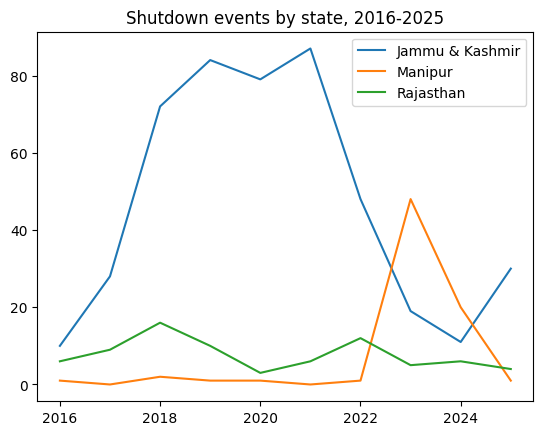

In [65]:
plt.figure()
for state in ['Jammu & Kashmir', 'Manipur', 'Rajasthan']:
    plt.plot(yearly_shutdowns_by_state['start_year'], yearly_shutdowns_by_state[state], label=state)
plt.legend()
plt.title('Shutdown events by state, 2016-2025') #this shows frequency not length

In [66]:
manipur_yearly = yearly_shutdowns_by_state[['start_year', 'Manipur']]
manipur_yearly

state,start_year,Manipur
0,2016,1
1,2017,0
2,2018,2
3,2019,1
4,2020,1
5,2021,0
6,2022,1
7,2023,48
8,2024,20
9,2025,1


In [67]:
jk_yearly = yearly_shutdowns_by_state[['start_year', 'Jammu & Kashmir']]
jk_yearly

state,start_year,Jammu & Kashmir
0,2016,10
1,2017,28
2,2018,72
3,2019,84
4,2020,79
5,2021,87
6,2022,48
7,2023,19
8,2024,11
9,2025,30


### **Analysis 5:** 

The biggest year(s) for **J&K = 2018 - 2021** (big jump only decline rly after 2021)

- 2018 - 2021 (big spike in 2018 - 2019, dropped in 2020 but stayed high and went back up to highest number of shutdowns in 2021 then significantly down in 2022. Went back up in 2025 after decreasing nearly back to number in 2016 when recordings began.

The biggest year(s) for **Manipur = 2023 - 2024 (mainly 2023 huge spike)**

- only 1 or none (besides 2018 when there were 2) from 2016 - 2023, the year there were 47. Went back down to 20 in 2024 and in 2025 down to just 1. 

The biggest year(s) for **Rajasthan = 2018 - 2019 (big jump in 2016, went down 2019 but still double digits - only double digits again in 2022)**

- 2018 - 2019 had double digits then back down in 2020 - 2022 when shutdowns went back to double digits and tback down in 2023. 


## **Step 10:** Finding human rights abuse and violence breakdown in top 3 states to compare to actual cause and government justification(J&K, Rajasthan, & Manipur) 
- the users targeted is very sparse for India so didn't include.

#### **Finding the human rights abuse recorded for internet shutdowns in Top 3 states. Show as yes, no or unknown.**

In [68]:
for state in ['Jammu & Kashmir', 'Manipur', 'Rajasthan']:
    print(state)
    print(india[india['state']==state]['hr_abuse_reported'].value_counts())
    print(india[india['state']==state]['violence'].value_counts())
    print()

hr_abuse_df = india[india['state'] != 'Rest of India'].groupby('state')['hr_abuse_reported'].value_counts().reset_index()
hr_abuse_df

Jammu & Kashmir
hr_abuse_reported
Unknown    335
No          18
Yes          2
Name: count, dtype: int64
violence
Yes        258
Unknown     67
No          33
Name: count, dtype: int64

Manipur
hr_abuse_reported
Unknown    69
Yes         3
Name: count, dtype: int64
violence
Yes    63
No      9
Name: count, dtype: int64

Rajasthan
hr_abuse_reported
Unknown    36
No         10
Name: count, dtype: int64
violence
Yes        26
Unknown    11
No          9
Name: count, dtype: int64



,state,hr_abuse_reported,count
0,Jammu & Kashmir,Unknown,335
1,Jammu & Kashmir,No,18
2,Jammu & Kashmir,Yes,2
3,Manipur,Unknown,69
4,Manipur,Yes,3
5,Rajasthan,Unknown,36
6,Rajasthan,No,10


#### **Finding violence recorded for internet shutdowns in Top 3 states. Show as yes, no or unknown and gives count**

In [69]:
violence_df = india[india['state'] != 'Rest of India'].groupby('state')['violence'].value_counts().reset_index()
violence_df

,state,violence,count
0,Jammu & Kashmir,Yes,258
1,Jammu & Kashmir,Unknown,67
2,Jammu & Kashmir,No,33
3,Manipur,Yes,63
4,Manipur,No,9
5,Rajasthan,Yes,26
6,Rajasthan,Unknown,11
7,Rajasthan,No,9


### **Analysis 6 :** 

J&K:
- human rights abuse reported numbers: 331 unknown, 17 no, 1 yes
- violence numbers: 66 unknown, 31 no, 254 yes 

Manipur:
- human rights abuse numbers:68 unknown, 3 yes. 
- violence numbers: 9 no, 62 yes

Rajasthan: 
- human rights abuse numbers: 36 unknown, 10 no. 
- violence numbers: 11 unknown, 9 no, 26 yes

**J&K has the highest number of internet shutdowns of the top 3 states where they're most concentrated but only has 1 human rights abuse recorded in Access Now dataset. All 3 states have high counts of violence recorded. For human rights abuse recorded many are unknown.**



## **Step 11:** Find the longest shutdowns in each of the top 3 areas of India that have the most frequent shutdowns and the type of shutdowns they have had between 2016 - 2025.

### ^^After running the code, it would appear that the shutdowns are broken down into separate recordings even when applying to the same situation in the dataset despite them being continous. For example, the 2019 shutdown in J&K was initially a full shutdown, then the region received 2G and then finally 4G in 2021, but overall it lasted 18 months. The longest recorded shutdown the code provides for J&K is from 2023 because it is still ongoing, but it is for a messaging app ban, so it's still a shutdown/restriction that is longer than the 18 month shutdown, but it is not necessarily as severe and it is not documented as separate shutdowns since it has remained the same unlike the 2019 scenario. 

#### Source for above: https://www.accessnow.org/after-a-partial-restoration-of-internet-access-in-jammu-kashmir-access-now-urges-full-access/ - Access Now 

#### **Find longest shutdowns in top 3 areas**

In [70]:
#Find the longest shutdowns in the top 3 states states with the most shutdowns w/ for loop : 

today = pd.Timestamp.today()
start_2016 = pd.Timestamp('2016-01-01')
days_list = []
for i, row in india.iterrows():
    start = row['start_date']
    end = row['end_date']
    if pd.isna(end) and row['shutdown_status'] == 'Ongoing':
        end = today
    if pd.isna(end):
        end = start
    if start < start_2016:
        start = start_2016
    days_list.append((end - start).days + 1)
india['days'] = days_list

In [71]:
india['state'] = 'Rest of India'
india.loc[india['area_name'].str.contains('Kashmir|Jammu', case=False, na=False), 'state'] = 'Jammu & Kashmir'
india.loc[india['area_name'].str.contains('Manipur', case=False, na=False), 'state'] = 'Manipur'
india.loc[india['area_name'].str.contains('Rajasthan', case=False, na=False), 'state'] = 'Rajasthan'

In [72]:
for state in ['Jammu & Kashmir', 'Manipur', 'Rajasthan']:
    
    longest = india[india['state'] == state].sort_values('days', ascending=False).iloc[0]
    
    print(state)
    print("area:", longest['area_name'])
    print("start:", longest['start_date'].date(), " end:", longest['end_date'])
    print("days:", longest['days'])
    print("actual cause:", longest['actual_cause'])
    print("gov justification:", longest['gov_justification'])
    print("hr_abuse_reported:", longest['hr_abuse_reported'], " violence:", longest['violence'])
    print("event notes:", longest['event'])
    
    print()

#Manipurs longest was actually from May 2023 until around October 2023 (5 months).

Jammu & Kashmir
area: Jammu & Kashmir
start: 2023-05-01  end: NaT
days: 1187
actual cause: Information control
gov justification: National Security/ Counter-Terrorism
hr_abuse_reported: No  violence: No
event notes: 14 messaging apps were blocked across all of India starting in early May 2023. Later court proceedings confirmed that the blocks were in fact limited to Jammu & Kashmir. The Delhi HC upheld the Briar ban largely because it was limited to J&K.

Manipur
area: 7 targeted zones across district boundaries, Manipur
start: 2024-03-02  end: 2024-03-17 00:00:00
days: 16
actual cause: Communal violence
gov justification: Fake News/ Hate Speech/ Incendiary Content/ Promoting Violence
hr_abuse_reported: Unknown  violence: Yes
event notes: According to an order dated Mar. 17, the home department had issued an order on Mar. 2 which targeted 7 zones previously under shutdown in February.

Rajasthan
area: Bharatpur, Karauli, Jaipur, Sawai Madhopur, in Rajasthan
start: 2020-10-30  end: 2020

In [73]:
print(india.columns)

Index(['start_date_type', 'start_date', 'country', 'geo_scope', 'area_name',
       'shutdown_type', 'affected_network', 'shutdown_extent', 'ordered_by',
       'decision_maker', 'actual_cause', 'actual_cause_details', 'info_source',
       'info_source_link', 'shutdown_status', 'end_date', 'duration',
       'gov_justification', 'gov_just_details', 'gov_ack', 'legal_just',
       'legal_method', 'gov_ack_source', 'gov_ack_quote', 'facebook_affected',
       'twitter_affected', 'whatsapp_affected', 'instagram_affected',
       'telegram_affected', 'other_affected', 'sms_affected',
       'phonecall_affected', 'telcos_involved', 'telco_ack',
       'telco_ack_source', 'telco_ack_quote', 'election', 'violence',
       'hr_abuse_reported', 'users_targeted', 'users_target_detail',
       'users_notified', 'econ_impact', 'event', 'an_link', 'region',
       'count_year', 'state', 'start_year', 'end_year', 'days'],
      dtype='str')


#### **Find the shutdown type in top 3 states** 

In [74]:
shutdown_type_df = india[india['state'] != 'Rest of India'].groupby('state')['shutdown_type'].value_counts().reset_index()
shutdown_type_df

,state,shutdown_type,count
0,Jammu & Kashmir,Shutdown,423
1,Jammu & Kashmir,"Shutdown, Throttle",28
2,Jammu & Kashmir,Throttle,16
3,Jammu & Kashmir,Unknown,1
4,Manipur,Shutdown,75
5,Rajasthan,Shutdown,75
6,Rajasthan,Throttle,1
7,Rajasthan,Unknown,1


#### **Find the shutdown extent in top 3 states** 

In [75]:
shutdown_extent_df = india[india['state'] != 'Rest of India'].groupby('state')['shutdown_extent'].value_counts().reset_index()
shutdown_extent_df

,state,shutdown_extent,count
0,Jammu & Kashmir,Full network,459
1,Jammu & Kashmir,Service-based,5
2,Jammu & Kashmir,"Full network, Service-based",4
3,Manipur,Full network,75
4,Rajasthan,Full network,71
5,Rajasthan,"Full network, Service-based",5
6,Rajasthan,Service-based,1


#### **Find the affected networks in top 3 states** 

In [76]:
affected_network_df = india[india['state'] != 'Rest of India'].groupby('state')['affected_network'].value_counts().reset_index()
affected_network_df

,state,affected_network,count
0,Jammu & Kashmir,Mobile,364
1,Jammu & Kashmir,"Broadband, Mobile",103
2,Jammu & Kashmir,Unknown,1
3,Manipur,Mobile,48
4,Manipur,"Broadband, Mobile",27
5,Rajasthan,Mobile,41
6,Rajasthan,"Broadband, Mobile",29
7,Rajasthan,Unknown,6
8,Rajasthan,Broadband,1


## **Here is the next CSV of the NSDP for J&K, Manipur and Rajasthan btwn 2016 - 2025. Important to note that their fiscal yr starts in April and ends in March and is in Rupees.Also this is SNDP so like GDP but for each state - not the whole country. Given all the variables that contribute to NSDP growth, I chose not to include it in my report but kept it here as an example for myself to reference as I used new tools, like Tabula, to retrieve this info.**

In [77]:
#nsdp = pd.read_csv("NSDP_by_State.csv") 

In [78]:
#nsdp = nsdp.drop(0)
#nsdp = nsdp.set_index('State/UT')
#nsdp = nsdp.astype(float)

In [79]:
#nsdp.head()

In [80]:
#nsdp.columns

In [81]:
#nsdp

In [82]:
#import matplotlib.pyplot as plt

In [83]:
#for state in nsdp.index:
   # plt.plot(nsdp.columns, nsdp.loc[state], label=state)
#plt.legend()
#plt.title('NSDP by state, 2016-2025')
#plt.xticks(rotation=45)

## **Import the World Bank "Individuals Using the Internet (% of population) - India.** This is to compare the percent of the country that is using internet from the start of Digital India to now in order to see how much internet has become part of society/daily life, in turn making these internet shutdowns all the more harmful. 

In [84]:
India_Internet_Users = pd.read_csv("Int_User_India.csv", skiprows=4)
India_Internet_Users

#kept getting an error when importing this CSV bc of info at the top of the csv so had to skip

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,97.170000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.300000,19.600000,21.600000,23.500000,25.000000,26.800000,27.800000,28.800000,30.4,NaN
2,Afghanistan,AFG,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,13.500000,16.799999,17.600000,17.048500,16.514299,15.866300,15.928400,16.094999,NaN,NaN
3,Africa Western and Central,AFW,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,23.800000,25.700000,28.500000,31.500000,34.700000,37.500000,38.500000,40.000000,42.4,NaN
4,Angola,AGO,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,26.000000,29.000000,32.129398,33.320900,34.556499,35.838001,37.885899,40.704800,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Kosovo,XKX,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,83.893597,89.443032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,"Yemen, Rep.",YEM,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,17.490999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,South Africa,ZAF,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,56.167400,62.400002,69.696899,72.112801,74.968597,78.293198,78.336700,78.357597,NaN,NaN
263,Zambia,ZMB,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,12.200000,14.299997,14.471900,14.645800,14.821900,15.000000,16.450701,17.101000,NaN,NaN


In [85]:
India_Internet_Users.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [86]:
India_Internet_Users = India_Internet_Users[India_Internet_Users["Country Name"] == "India"]
India_Internet_Users

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
108,India,IND,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.200001,20.0813,29.5235,43.405443,49.258099,55.9,60.2523,64.943497,70.0,NaN


In [87]:
#Find the number of internet users each yr in india from 2015 (yr Digital India introduced)
India_Internet_Users = India_Internet_Users[["Country Name", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]]
India_Internet_Users.to_csv("India's_Yearly_Internet_Users.csv.", index=False)

#India_Internet_Users[["Country Name", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]]

In [88]:
check = pd.read_csv("India's_Yearly_Internet_Users.csv")
check

,Country Name,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,India,14.9,16.5,18.200001,20.0813,29.5235,43.405443,49.258099,55.9,60.2523,64.943497,70.0


## **CSV files are saved below in one spot**

In [100]:
state_df.to_csv("India_State_Shutdown_Frequency.csv", index=False)
#this shows total number of shutdowns each country has experienced btwn 2016 - 2025
#the numbers are very large because it isn't by day, it's by how many total, so many could've 
#happened in just one day across multiple parts of one country.

In [101]:
df_frequency.to_csv("Frequency_By_Country.csv", index=False)
#this shows India (907) has the most internet shutdowns in Stop dataset

In [102]:
govJustification_df.to_csv("Gov_Justification_Top3Shutdown_Areas.csv", index=False)
#this shows the top 5 reasons the government has claimed the internet shutdown was necessary
#as seen in the DF, the top 3 regions used don't all have 5 justification sections.

In [103]:
state_summary_df.to_csv("State_Days_Count_AvgLen.csv", index=False)

In [104]:
actualCause_df.to_csv("India_Actual_Cause_Shutdowns.csv", index=False)

In [105]:
gov_justification_all_India_df.to_csv("All_India_Gov_Justifications", index=False)

In [106]:
yearly_shutdowns_by_state.to_csv("Yearly_Shutdowns_By_Top3_States.csv", index=False)

In [107]:
manipur_yearly.to_csv("Yearly_Manipur_Bar_Chart.csv", index=False)

In [108]:
rajasthan_causes.to_csv("Rajasthan_Actual_Causes.csv", index=False)

In [109]:
jk_yearly.to_csv("J&K_Yearly_Shutdowns.csv", index=False)

In [110]:
India_Internet_Users.to_csv("India's_Yearly_Internet_Users.csv", index=False) 